# 4. 动态评估法
贝尔曼方程只对小问题有效。在实践中，当状态和行动模式的数量稍有增加，这种方法就会变得难以使用。对于这样的情况应运而生了动态规划法

## 4.1 动态规划法和策略评估
强化学习的问题通常涉及：策略评估和策略控制  
策略评估是求给定策略 $\pi$ 的价值函数 $v_\pi(s)$ 和 $q_\pi(s,a)$，策略控制是控制策略并将其调整为最优策略
强化学习的最终目标是策略控制，但为实现这一目标需要进行策略评估，现在通过动态规划法（DP）的算法进行策略评估

### 4.1.1 动态规划法简介

使用DP的方法也是从贝尔曼方程通过“更新式”衍生而来，通过用估计值来改进另一个估计值的自举法来完成更迭，这种算法被称为迭代策略评估
$$
V_{k+1}(s)=\sum_{a,s'} \pi(a|s)p(s'|s,a) \left\{r(s,a,s') + \gamma V_k(s')\right\}
$$

## 4.2 更大的问题

### 4.2.1 GridWorld类的实现

In [ ]:
import numpy as np

class GridWorld:
    def __init__(self):
        self.action_space = [0, 1, 2, 3]
        self.action_meaning = {
            0: 'UP',
            1: 'DOWN',
            2: 'LEFT',
            3: 'RIGHT',
        }

        self.reward_map = np.array(
            [[0, 0, 0, 1.0],
             [0, None, 0, -1.0],
             [0, 0, 0, 0]]
        )
        self.goal_state = (0, 3)
        self.wall_state = (1, 1)
        self.start_state = (2, 0)
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])

    @property
    def shape(self):
        return self.reward_map.shape

    def actions(self):
        return self.action_space # [0, 1, 2, 3]

    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield(h, w)

In [10]:
env = GridWorld()

print(env.height)
print(env.width)
print(env.shape)

for action in env.actions():
    print(action)

print('===')

for state in env.states():
    print(state)

3
4
(3, 4)
0
1
2
3
===
(0, 0)
(0, 1)
(0, 2)
(0, 3)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(2, 0)
(2, 1)
(2, 2)
(2, 3)


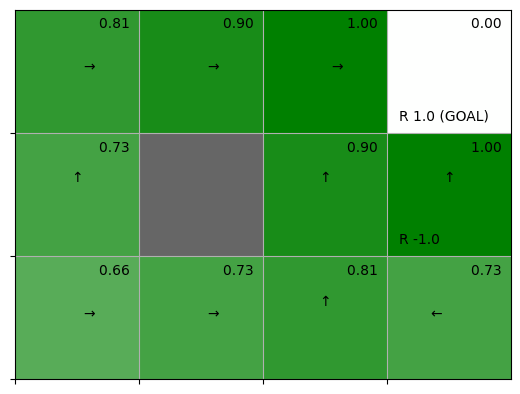

In [20]:
import numpy as np
import res.common.gridworld_render as render_helper
from collections import defaultdict

class GridWorld:
    def __init__(self):
        self.action_space = [0, 1, 2, 3]
        self.action_meaning = {
            0: 'UP',
            1: 'DOWN',
            2: 'LEFT',
            3: 'RIGHT',
        }

        self.reward_map = np.array(
            [[0, 0, 0, 1.0],
             [0, None, 0, -1.0],
             [0, 0, 0, 0]]
        )
        self.goal_state = (0, 3)
        self.wall_state = (1, 1)
        self.start_state = (2, 0)
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])

    @property
    def shape(self):
        return self.reward_map.shape

    def actions(self):
        return self.action_space # [0, 1, 2, 3]

    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield(h, w)

    def next_state(self, state, action):
        # 移动目的地的计算
        action_move_map = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        move = action_move_map[action]
        next_state = (state[0] + move[0], state[1] + move[1])
        ny, nx = next_state

        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height: # 判断是否出界
            next_state = state
        elif next_state == self.wall_state: # 判断是否撞墙
            next_state = state
        return next_state # 返回下一状态
        # 因为这个人物中状态迁移是确定性的，所以直接返回

    def reward(self, state, action, next_state):
        return self.reward_map[next_state]


    def render_v(self, v=None, policy=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

def argmax(d):
    max_value = max(d.values())
    max_key = 0
    for key,value in d.items():
        if value == max_value:
            max_key = key
    return max_key

def greedy_policy(V, env, gamma):
        pi = {}
        
        for state in env.states():
            action_values = {}
        
            for action in env.actions():
                next_state = env.next_state(state, action)
                r = env.reward(state, action, next_state)
                value = r + gamma * V[next_state]
                action_values[action] = value
            
            max_action = argmax(action_values)
            action_probs = {0: 0, 1:0, 2:0, 3:0}
            action_probs[max_action] = 1.0
            pi[state] = action_probs
        
        return pi

def eval_onestep(pi, V, env, gamma=0.9):
    '''
    pi:策略
    V:价值函数
    env:环境
    gamma:折现率
    '''
    for state in env.states(): # 访问各个状态
        if state == env.goal_state: # 目的地的价值函数总是为0 —— 终止状态
            V[state] = 0
            continue
        
        action_probs = pi[state]
        new_V = 0
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V

def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy() # 更新前的价值函数
        V = eval_onestep(pi, V, env, gamma)

        # 求更新量的最大值
        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        # 与阈值比较
        if delta < threshold:
            break
    
    return V

def policy_iter(env, gamma, threshold=0.001, is_render=False):
    pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi
    
    return pi

env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})
V = defaultdict(lambda:0) # 任何未定义的状态，自动返回0
pi = policy_iter(env, gamma)
V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

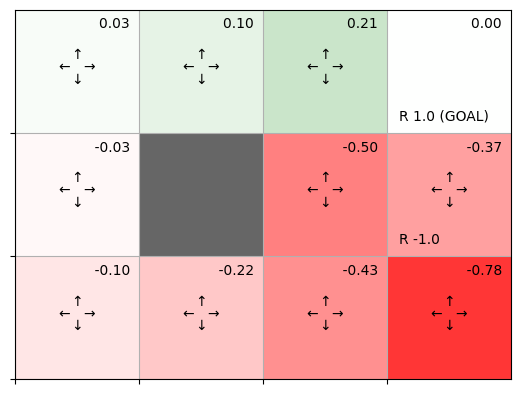

In [18]:
from collections import defaultdict

env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})
V = defaultdict(lambda:0) # 任何未定义的状态，自动返回0

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

实现随机性策略，按照均匀随机往四周的概率都是1/4

In [ ]:
pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})

state = (0, 1)
print(pi[state])

{0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}


In [ ]:
def eval_onestep(pi, V, env, gamma=0.9):
    '''
    pi:策略
    V:价值函数
    env:环境
    gamma:折现率
    '''
    for state in env.states(): # 访问各个状态
        if state == env.goal_state: # 目的地的价值函数总是为0
            V[state] = 0
            continue
        
        action_probs = pi[state]
        new_V = 0

        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)

            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V

In [ ]:
def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy() # 更新前的价值函数
        V = eval_onestep(pi, V, env, gamma)

        # 求更新量的最大值
        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        # 与阈值比较
        if delta < threshold:
            break
    
    return V

### 4.3 策略迭代法

我们的目标是得到最优策略。实现这个目标的一种方法是解出一组满足贝尔曼最优方程的联立方程。不过这种方法的计算量非常大，当当状态的大小为S、行动的大小为A时，求解将需要$A^S$的计算量

### 4.3.1 策略的改进
最优的策略使用以下符号介绍如何改进
- 最优策略：$\mu_*(s)$
- 最优策略的状态价值函数：$v_*(s)$
- 最优策略的行动价值函数：$q_*(s,a)$

最优策略：$\mu_*(s)$
$$
\begin{align}
\mu_*(s) &= \argmax_aq_*(s,a) \\
&= \argmax_a \sum_{s'}p(s'|s,a) \left \{ r(s,a,s')+\gamma v_*(s')\right \}
\end{align}
$$
最优策略是由$\argmax\limits_a$通过取最大值的行动a所决定，由于这个原因得到的策略也被称为贪婪策略

由 $\mu_*(s) = \argmax_aq_*(s,a) $
$$
\begin{align}
\mu'(s) &= \argmax_aq_\mu(s,a) \\
&= \argmax_a\sum_{s'}p(s'|s,a)\left\{ r(s,a,s') + \gamma v_\mu(s') \right\}
\end{align}
$$

- 当前策略：$\mu(s)$
- 策略$\mu(s)$的状态价值函数：$v_\mu(s)$
- 新的策略：$\mu'(s)$

通过此策略更新的做法叫做贪婪化
策略贪婪化意味着
- 策略总是被改进
- 如果该策略没有被改进，那么它就是最优策略

### 4.3.2 重复评估和改进
策略迭代法

## 4.4 实施策略迭代法

### 4.4.1 改进策略
为了改进策略，先基于当前价值函数得到贪婪策略
$$
\mu'(s) = \argmax_a \sum_{s'}p(s'|s,a) \left\{r(s,a,s') + \gamma v_\mu(s') \right\}
$$
因为这个问题中的状态迁移是唯一的，当$s'=f(s,a)$时
$$
\mu'(s) = \argmax_a \left\{ r(s,a,s') + \gamma v_\mu(s') \right\}
$$

In [9]:
def argmax(d):
    max_value = max(d.values())
    max_key = 0
    for key,value in d.items():
        if value == max_value:
            max_key = key
    return max_key

action_values = {0:0.1 , 1:-0.3, 2:9.9, 3:-1.3}

max_action = argmax(action_values)
print(max_action)

2


由此实现将价值函数贪婪化的函数

In [ ]:
def greedy_policy(V, env, gamma):
    pi = {}
    
    for state in env.states():
        action_values = {}
    
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value
        
        max_action = argmax(action_values)
        action_probs = {0: 0, 1:0, 2:0, 3:0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    
    return pi

### 4.4.2 重复评审和改进

In [ ]:
def policy_iter(env, gamma, threshold=0.001, is_render=False):
    pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi
    
    return pi

## 4.5 价值迭代法

### 4.5.1 价值迭代法的推导